# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [1]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [2]:
coffee_df = pd.read_csv("./data/coffee_shop_lab.csv")

##### 2.❓Now preview the first 5 rows of the data.

In [3]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [4]:

coffee_df.shape

(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [5]:
coffee_df.dtypes


transaction_date               str
transaction_time               str
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group                  str
product_category               str
product_type                   str
current_wholesale_price    float64
customer_since                 str
customer_birth_year        float64
customer_generation            str
dtype: object

> 👉 **Write Your Findings Here**: 
-- - transaction date and customer since are str
> 

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [6]:

coffee_df["transaction_date"]= pd.to_datetime(coffee_df["transaction_date"])
coffee_df["customer_since"]= pd.to_datetime(coffee_df["customer_since"])



##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [53]:

coffee_df.isnull().mean()*100
# by storing the missing data as unknown 

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
total_wholesale_amount      0.000000
profit                      0.000000
profit_ratio                0.000000
transaction_day             0.000000
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [8]:
coffee_df.duplicated().sum()


np.int64(149)

In [11]:
coffee_df = coffee_df.drop_duplicates()
coffee_df.duplicated().sum()


np.int64(0)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [54]:
list(coffee_df["product_group"].unique())


['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']

In [55]:
list(coffee_df["product_category"].unique())



['Tea',
 'Coffee',
 'Drinking Chocolate',
 'Bakery',
 'Coffee beans',
 'Flavours',
 'Loose Tea',
 'Packaged Chocolate',
 'Branded']

In [56]:

list(coffee_df["product_type"].unique())


['Brewed Chai tea',
 'Organic brewed coffee',
 'Brewed Green tea',
 'Drip coffee',
 'Premium brewed coffee',
 'Gourmet brewed coffee',
 'Brewed Black tea',
 'Hot chocolate',
 'Barista Espresso',
 'Scone',
 'Brewed herbal tea',
 'Biscotti',
 'Pastry',
 'Organic Beans',
 'Regular syrup',
 'Herbal tea',
 'Gourmet Beans',
 'Black tea',
 'Sugar free syrup',
 'House blend Beans',
 'Premium Beans',
 'Chai tea',
 'Organic Chocolate',
 'Drinking Chocolate',
 'Green beans',
 'Green tea',
 'Espresso Beans',
 'Housewares',
 'Clothing']

In [57]:
list(coffee_df["customer_generation"].unique())



['Older Millennials',
 'Baby Boomers',
 'Gen Z',
 'Gen X',
 'Younger Millennials',
 nan]

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [24]:

coffee_df.describe()

,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year,total_wholesale_amount,profit
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000,49745.000000,49745.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.687731,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871,1.750993,2.936738
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000,0.040000,-6.330000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000,0.640000,1.600000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000,1.200000,2.400000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000,2.110000,3.920000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000,288.000000,72.000000
std,NaN,3247.554091,0.543316,4.441833,2.686402,2.204466,NaN,15.088333,3.465079,1.914386


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [25]:
coffee_df["total_wholesale_amount"] = coffee_df["current_wholesale_price"] * coffee_df["quantity"]

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [26]:
coffee_df["profit"] = coffee_df["line_item_amount"] - coffee_df["total_wholesale_amount"]

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74


##### 13.❓Find the highest sale price in the dataset.

In [60]:
coffee_df["line_item_amount"].max()



np.float64(360.0)

##### 14.❓Find the largest amount of profit.

In [28]:
coffee_df["profit"].max()



np.float64(72.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [29]:
coffee_df["profit"].mean()


np.float64(2.9367379636144335)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [30]:

len(coffee_df[coffee_df["line_item_amount"] > coffee_df["line_item_amount"].mean()
])


19544

##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [31]:
coffee_df["profit_ratio"] = coffee_df["line_item_amount"] / coffee_df["total_wholesale_amount"]

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [32]:
len(coffee_df[coffee_df["profit_ratio"] >= 2])


37260

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [34]:
len(coffee_df[coffee_df["product_type"].str.contains("beans",case=False, na=False)])



587

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [35]:
coffee_df.sort_values("profit", ascending=False).head(1)




,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49092,2019-04-17,09:55:47,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,NaT,NaN,NaN,288.0,72.0,1.25


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [39]:
loss = coffee_df[coffee_df["profit"] < 0]

print("Number of loss transactions:", len(loss))
loss.head(10)


Number of loss transactions: 151


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
37654,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,0.409836
37656,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,0.409836
37658,2019-04-07,08:39:48,5736.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-01-04,1980.0,Older Millennials,2.44,-1.44,0.409836
37659,2019-04-07,10:10:26,5563.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-01-01,1998.0,Gen Z,2.44,-1.44,0.409836
37662,2019-04-07,10:29:12,5083.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-02-10,1999.0,Gen Z,2.44,-1.44,0.409836
37665,2019-04-07,08:16:00,5701.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-08-23,1995.0,Gen Z,2.44,-1.44,0.409836
37666,2019-04-07,09:09:12,5685.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-08-16,1985.0,Older Millennials,2.44,-1.44,0.409836
37667,2019-04-07,07:14:22,5453.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-08-26,1964.0,Baby Boomers,2.44,-1.44,0.409836
37694,2019-04-08,15:50:48,30.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-03-25,1955.0,Baby Boomers,2.44,-1.44,0.409836
37695,2019-04-08,12:08:15,15.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-12,1952.0,Baby Boomers,2.44,-1.44,0.409836


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your finding here please:
- Looking at the loss transactions, many of them have a `line_item_amount` that doesn't match `unit_price * quantity`. For example, some rows show a `line_item_amount` of 0 or 1, even though the `unit_price` and `quantity` say it should be higher. This looks like a **data entry error**, not a genuine loss.


##### 22.❓Correct the line item amount column with the correct values

In [40]:
coffee_df["line_item_amount"] = coffee_df["unit_price"] * coffee_df["quantity"]

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [42]:
coffee_df["profit"] = coffee_df["line_item_amount"] - coffee_df["total_wholesale_amount"]

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [44]:
loss_transactions = coffee_df[coffee_df["profit"] < 0]

print("Number of loss transactions:", len(loss_transactions))
loss_transactions


Number of loss transactions: 2


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-02-10,1975.0,Gen X,18.0,-6.0,0.666667
46268,2019-04-07,10:56:05,5656.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-03-05,1954.0,Baby Boomers,18.0,-6.0,0.666667


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [48]:
product_group_counts = coffee_df["product_group"].value_counts()
product_group_counts


product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

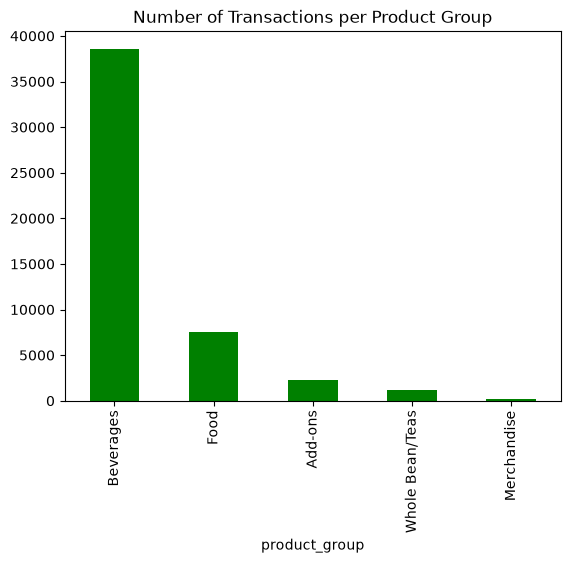

In [85]:
product_group_counts.plot(kind="bar", color="green")
plt.title("Number of Transactions per Product Group");


##### 27.❓Can you calculate the median profit for each product type?

In [62]:
median_profit_by_type = coffee_df.groupby("product_type")["profit"].median().sort_values(ascending=False)
median_profit_by_type


product_type
Clothing                 19.04
Housewares                9.52
Premium Beans             9.00
Gourmet Beans             4.20
Premium brewed coffee     3.92
Brewed Black tea          3.74
Brewed Chai tea           3.74
Brewed Green tea          3.74
Brewed herbal tea         3.74
House blend Beans         3.60
Organic Beans             3.60
Organic brewed coffee     3.52
Barista Espresso          3.40
Gourmet brewed coffee     3.20
Espresso Beans            2.95
Drinking Chocolate        2.67
Drip coffee               2.40
Green beans               2.00
Chai tea                  1.90
Green tea                 1.85
Herbal tea                1.79
Black tea                 1.79
Hot chocolate             1.74
Regular syrup             1.52
Sugar free syrup          1.52
Organic Chocolate         1.52
Pastry                    1.31
Biscotti                  1.22
Scone                     1.14
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [63]:
coffee_df["transaction_day"] = coffee_df["transaction_date"].dt.day_name()

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [64]:
revenue_by_day = coffee_df.groupby("transaction_day")["line_item_amount"].sum().sort_values(ascending=False)
revenue_by_day



transaction_day
Monday       39692.99
Wednesday    34442.58
Tuesday      32500.26
Friday       32326.55
Saturday     32210.10
Thursday     31944.82
Sunday       31094.25
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

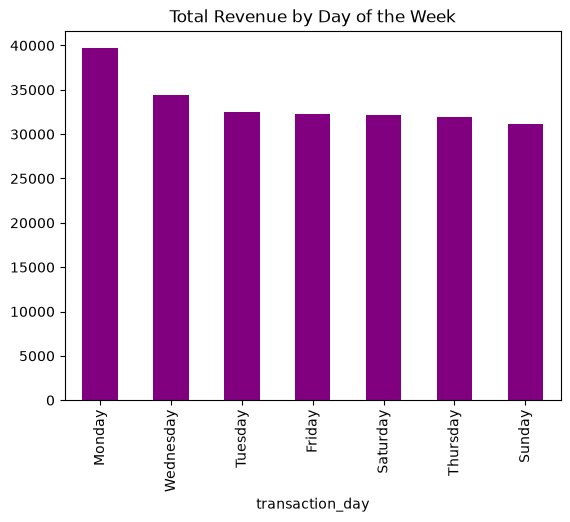

In [65]:
revenue_by_day.plot(kind="bar", color="purple")
plt.title("Total Revenue by Day of the Week");


##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [66]:
total_spend_by_generation = coffee_df.groupby("customer_generation")["line_item_amount"].sum().sort_values(ascending=False)
total_spend_by_generation


customer_generation
Baby Boomers           27355.89
Gen X                  26764.36
Older Millennials      25215.90
Gen Z                  19759.10
Younger Millennials    15458.63
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

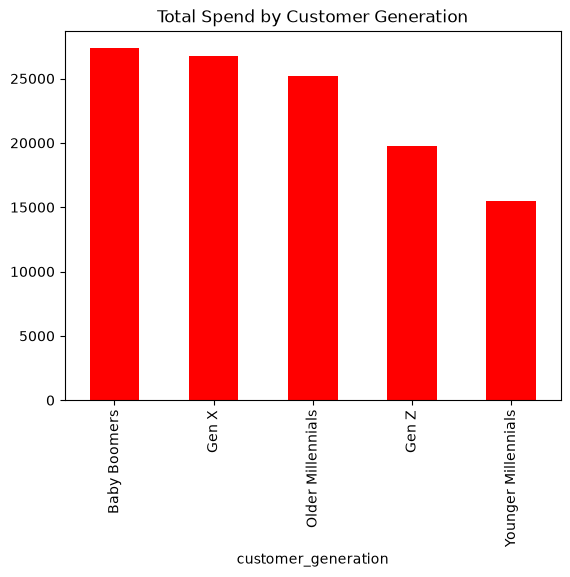

In [67]:
total_spend_by_generation.plot(kind="bar", color="red")
plt.title("Total Spend by Customer Generation");


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please: **No**

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [68]:
top5_profit_by_type = coffee_df.groupby("product_type")["profit"].sum().sort_values(ascending=False).head(5)
top5_profit_by_type


product_type
Barista Espresso         24599.50
Brewed Chai tea          19240.00
Gourmet brewed coffee    18944.72
Brewed Black tea         11952.20
Brewed herbal tea        11835.17
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

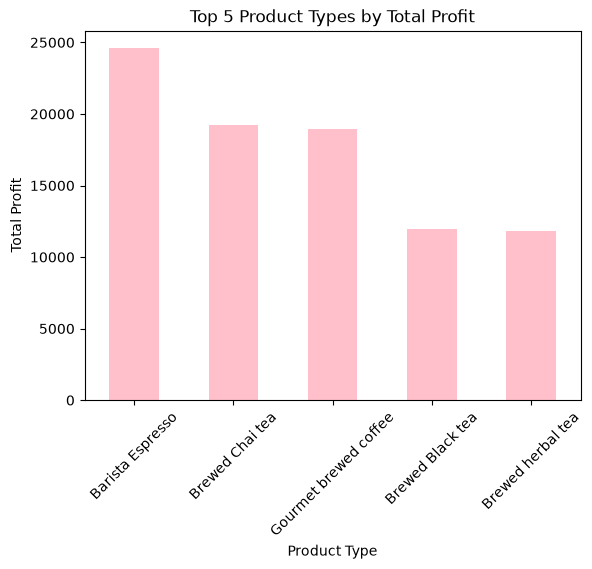

In [70]:
top5_profit_by_type.plot(kind="bar", color="pink")
plt.title("Top 5 Product Types by Total Profit")
plt.xlabel("Product Type")
plt.ylabel("Total Profit")
plt.xticks(rotation=45);


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [86]:
avg_profit_ratio_by_generation = coffee_df.groupby("customer_generation")["profit_ratio"].mean().sort_values(ascending=False)
avg_profit_ratio_by_generation.head()

customer_generation
Younger Millennials    0.341304
Baby Boomers           0.341105
Gen X                  0.340531
Gen Z                  0.339128
Older Millennials      0.339021
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

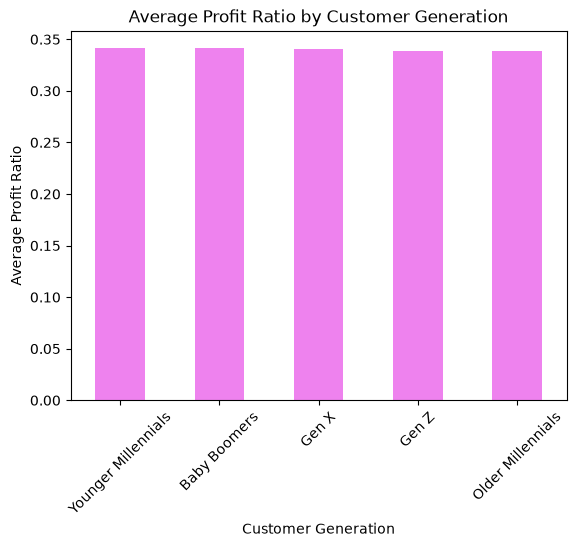

In [87]:
avg_profit_ratio_by_generation.plot(kind="bar", color="violet")
plt.title("Average Profit Ratio by Customer Generation")
plt.xlabel("Customer Generation")
plt.ylabel("Average Profit Ratio")
plt.xticks(rotation=45);




## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [73]:
# Extracting dates from transaction date

coffee_df["transaction_day"] = coffee_df["transaction_date"].dt.day_name()
coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday


In [75]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time

def time_category(transaction_time):
    hour = int(transaction_time.split(":")[0])

    if hour >=5 and hour<12:
        return "Morning"
    elif hour >=12 and hour <17:
        return "Noon"
    elif hour>= 17 and hour < 21:
        return "Evening"
    else:
        return "Night"
# use apply to apply the time category into a new column called time_category

coffee_df["time_category"] = coffee_df["transaction_time"].apply(time_category)

coffee_df.head()







,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,0.252,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,0.252,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,0.252,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,0.252,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,0.252,Monday,Evening


transaction_day
Monday       39692.99
Wednesday    34442.58
Tuesday      32500.26
Friday       32326.55
Saturday     32210.10
Thursday     31944.82
Sunday       31094.25
Name: line_item_amount, dtype: float64


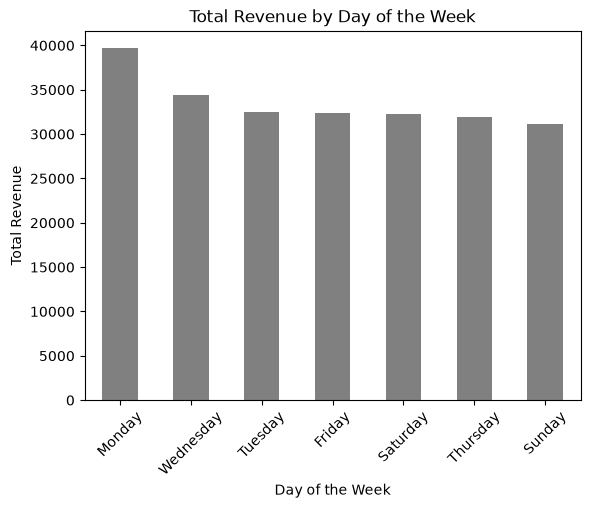

In [88]:
# Are there better or worse days in terms of sales?
revenue_by_day = coffee_df.groupby("transaction_day")["line_item_amount"].sum().sort_values(ascending=False)
print(revenue_by_day)

revenue_by_day.plot(kind="bar", color="grey")
plt.title("Total Revenue by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45);

# Write your findings


> 👉 **Write Your Findings Here**:
- Monday brings the most total revenue while sunday brings in the least.And the jump between week days isnt that huge.But Monday stands out, possibly because people grap there coffee on their way back from a weekend 
-- -

time_category
Morning    129017.97
Noon        68923.41
Evening     35744.64
Night         525.53
Name: line_item_amount, dtype: float64


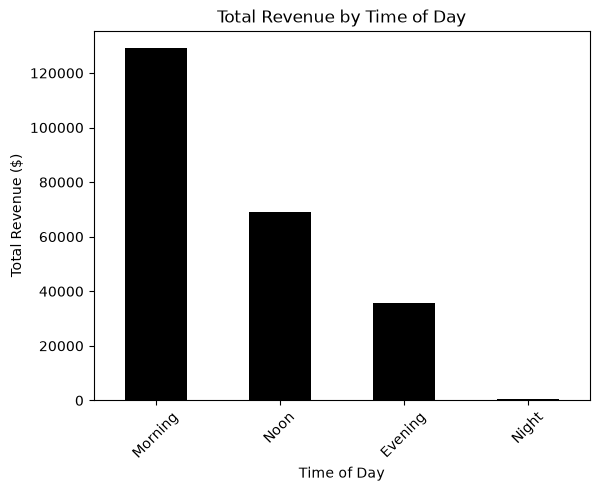

In [89]:
# Are there better or worse times of day in terms of sales?
revenue_by_time = coffee_df.groupby("time_category")["line_item_amount"].sum().sort_values(ascending=False)
print(revenue_by_time)

revenue_by_time.plot(kind="bar", color="black")
plt.title("Total Revenue by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()

# Write your findings


> 👉 **Write Your Findings Here**:
- what we could conclude from the bar chart is that the busiest time for revenue is the Morning follwed by Noon. Evening brings in much less revenue and Night almost bring no revenue Morning is by far the busiest time for revenue, followed by Noon. Evening brings in much less, and Night is almost empty. Which makes sense taking the fact that this is a coffee shop and most people buy there coffee in the morning. 
-- -

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

customer_generation
Gen X                  3.061517
Gen Z                  3.056305
Baby Boomers           3.050430
Older Millennials      3.048419
Younger Millennials    3.027815
Name: unit_price, dtype: float64


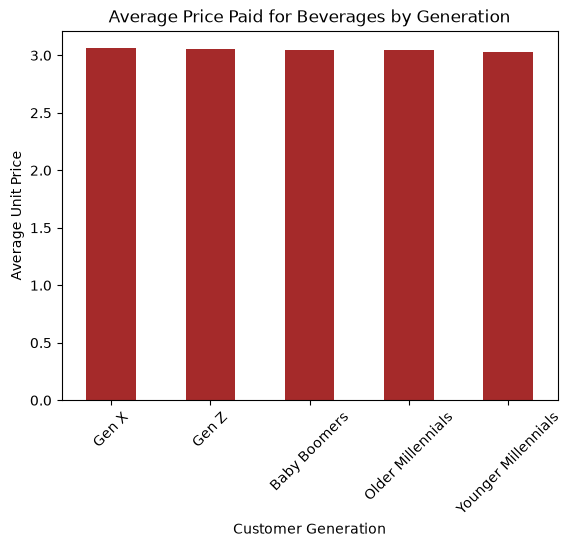

In [96]:
# First, keep only the rows where the product_group is "Beverages"
beverages_df = coffee_df[coffee_df["product_group"] == "Beverages"]

avg_price_by_generation = beverages_df.groupby("customer_generation")["unit_price"].mean().sort_values(ascending=False)
print(avg_price_by_generation)

avg_price_by_generation.plot(kind="bar", color="brown")
plt.title("Average Price Paid for Beverages by Generation")
plt.xlabel("Customer Generation")
plt.ylabel("Average Unit Price")
plt.xticks(rotation=45);

# Write your findings


> 👉 **Write Your Findings Here**:
> The observation that is shown by the bar chart is that across all generations the average price paid for beverages is very similar. Gen X has the highest attribution out of all slightly over $3 and the lowest attribution goes to Younger Millennials. 

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

In [91]:
from datetime import date

# today's date, so we can measure how long each customer has been with us
today = pd.Timestamp(date.today())

# customer_tenure_days = number of days between today and when they became a customer
coffee_df["customer_tenure_days"] = (today - coffee_df["customer_since"]).dt.days

coffee_df.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category,customer_tenure_days
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,0.252,Monday,Noon,2941.0
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,0.252,Monday,Morning,3414.0
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,0.252,Monday,Noon,2732.0
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,0.252,Monday,Noon,3253.0
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,0.252,Monday,Evening,2985.0


Correlation between tenure and spend: 0.010157462251708067


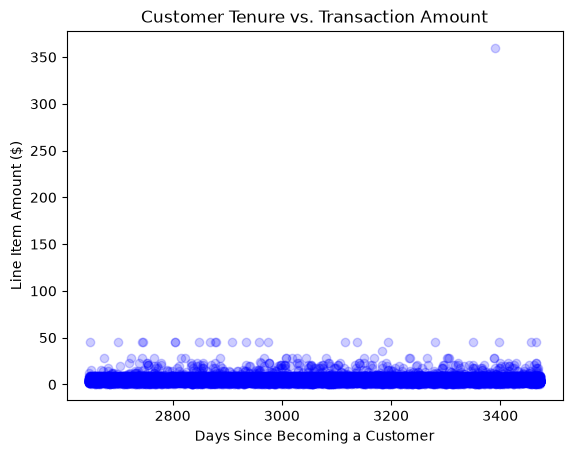

In [92]:
plt.scatter(coffee_df["customer_tenure_days"], coffee_df["line_item_amount"], alpha=0.2, color="blue")
plt.title("Customer Tenure vs. Transaction Amount")
plt.xlabel("Days Since Becoming a Customer")
plt.ylabel("Line Item Amount ($)")

correlation = coffee_df["customer_tenure_days"].corr(coffee_df["line_item_amount"])
print("Correlation between tenure and spend:", correlation)

# Write your findings: The correlation is very close to 0, and the scatter plot shows no clear pattern.
